## Modeling-1 : SMARD + Weather - LSTM

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading both SMARD and OpenMeteo data

In [108]:
df_smard = pd.read_csv("Combined_smard_data.csv")
df_om    = pd.read_csv("Open_Meteo_combined_2019-05-01_to_2026-05-01.csv")

### Preparing the SMARD data

In [109]:
df_smard['Start_date'] = pd.to_datetime(df_smard['Start_date'])

In [110]:
check_date = '2023-10-29'

# Filter for rows on that day between 01:00 and 04:00
dst_morning = df_smard[
    (df_smard['Start_date'].dt.date == pd.to_datetime(check_date).date()) & 
    (df_smard['Start_date'].dt.hour.isin([1, 2, 3, 4]))
]

print(f" SMARD timestamps on {check_date}:")
print(dst_morning['Start_date'])


 SMARD timestamps on 2023-10-29:
39409   2023-10-29 01:00:00
39410   2023-10-29 02:00:00
39411   2023-10-29 02:00:00
39412   2023-10-29 03:00:00
39413   2023-10-29 04:00:00
Name: Start_date, dtype: datetime64[us]


We see that 2:00:00 appears twice. To avoid errors and maintain consistency with OpenMeteo data, we convert it to UTC

In [111]:
df_smard['Start_date_utc'] = df_smard['Start_date'].dt.tz_localize('Europe/Berlin',ambiguous='infer',nonexistent='shift_forward')
df_smard['Start_date_utc'] = df_smard['Start_date_utc'].dt.tz_convert('UTC')

## Strip +0:0 suffix
df_smard['Start_date_utc'] = df_smard['Start_date_utc'].dt.tz_localize(None)

In [112]:

check_df = df_smard[df_smard['Start_date_utc'].dt.date == pd.to_datetime(check_date).date()]


print(check_df[['Start_date', 'Start_date_utc']].iloc[0:8])

               Start_date      Start_date_utc
39410 2023-10-29 02:00:00 2023-10-29 00:00:00
39411 2023-10-29 02:00:00 2023-10-29 01:00:00
39412 2023-10-29 03:00:00 2023-10-29 02:00:00
39413 2023-10-29 04:00:00 2023-10-29 03:00:00
39414 2023-10-29 05:00:00 2023-10-29 04:00:00
39415 2023-10-29 06:00:00 2023-10-29 05:00:00
39416 2023-10-29 07:00:00 2023-10-29 06:00:00
39417 2023-10-29 08:00:00 2023-10-29 07:00:00


In [113]:
df_smard['Start_date'] = df_smard['Start_date_utc']
df_smard.drop(columns=['Start_date_utc'])

,Start_date,Biomass,Hydro,Wind_offshore,Wind_onshore,Photovolt,Other_ren,Nuclear,Lignite,Hard_coal,...,Other_conv,Renewables_tot,Renewables_frac,Solar_frac,Wind_onshore_frac,Hydro_frac,Total_gen,Residuals,Price,Negative_price
0,2019-04-30 22:00:00,4608.75,2123.75,1222.25,6336.00,0.00,171.50,6630.50,11257.00,3311.75,...,1470.50,14462.25,0.343155,0.000000,0.438106,0.233159,42145.00,37112.50,38.00,0
1,2019-04-30 23:00:00,4590.25,2120.50,1168.75,5916.50,0.00,174.25,6626.50,11035.00,2850.25,...,1478.50,13970.25,0.345164,0.000000,0.423507,0.230060,40474.25,35420.75,35.20,0
2,2019-05-01 00:00:00,4597.75,2052.00,1386.00,5750.00,0.00,178.25,6634.25,11090.50,2604.50,...,1490.25,13964.00,0.352426,0.000000,0.411773,0.179909,39622.50,33752.25,32.64,0
3,2019-05-01 01:00:00,4593.50,2086.75,1502.75,6128.50,0.00,179.25,6637.25,11082.50,2524.00,...,1483.25,14490.75,0.368047,0.000000,0.422925,0.152684,39372.00,32877.50,31.16,0
4,2019-05-01 02:00:00,4592.75,2118.50,1671.50,6520.50,0.00,181.00,6638.00,10267.25,2507.50,...,1495.75,15084.25,0.385789,0.000000,0.432272,0.152295,39099.75,32177.25,29.56,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61369,2026-04-30 23:00:00,4082.65,1326.17,4978.31,14142.98,0.00,94.88,NaN,4638.71,1642.62,...,1808.27,24624.99,0.643847,0.000000,0.574334,0.123221,38246.67,22355.53,103.09,0
61370,2026-05-01 00:00:00,4068.31,1300.59,4167.01,13490.25,0.00,95.38,NaN,4536.85,1637.41,...,1808.34,23121.54,0.645024,0.000000,0.583449,0.095945,35846.03,22070.26,101.39,0
61371,2026-05-01 01:00:00,4067.04,1283.89,3511.52,12810.96,0.00,95.88,NaN,4582.56,1636.92,...,1803.15,21769.29,0.613966,0.000000,0.588488,0.145395,35456.81,22776.94,99.25,0
61372,2026-05-01 02:00:00,4115.12,1259.85,3130.70,12204.60,0.00,95.88,NaN,4620.36,1630.67,...,1806.87,20806.15,0.611440,0.000000,0.586586,0.122138,34028.14,23903.28,97.98,0


In [114]:
df_smard.columns

Index(['Start_date', 'Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore',
       'Photovolt', 'Other_ren', 'Nuclear', 'Lignite', 'Hard_coal',
       'Fossil_gas', 'Hydro_pump_stor', 'Other_conv', 'Renewables_tot',
       'Renewables_frac', 'Solar_frac', 'Wind_onshore_frac', 'Hydro_frac',
       'Total_gen', 'Residuals', 'Price', 'Negative_price', 'Start_date_utc'],
      dtype='str')

In [115]:
df_smard['Hour'] = df_smard['Start_date'].dt.hour
df_smard['Day_of_week'] = df_smard['Start_date'].dt.dayofweek
df_smard['Month'] = df_smard['Start_date'].dt.month

In [116]:
df_smard['Nuclear_gap'] = df_smard['Nuclear'].isna().astype(int)
df_smard['Nuclear'] = df_smard['Nuclear'].fillna(0)

### Preparing the weather data for merging

In [117]:
df_om['timestamp_utc'] = pd.to_datetime(df_om['timestamp_utc'])
df_om['timestamp_utc'] = df_om['timestamp_utc'].dt.tz_localize(None)
df_om['timestamp_utc']

0         2019-05-01 00:00:00
1         2019-05-01 00:00:00
2         2019-05-01 00:00:00
3         2019-05-01 00:00:00
4         2019-05-01 00:00:00
                  ...        
1105051   2026-05-01 23:00:00
1105052   2026-05-01 23:00:00
1105053   2026-05-01 23:00:00
1105054   2026-05-01 23:00:00
1105055   2026-05-01 23:00:00
Name: timestamp_utc, Length: 1105056, dtype: datetime64[us]

In [118]:
df_om.head()

,timestamp_utc,point_id,region,feature_groups,latitude,longitude,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,...,surface_pressure,shortwave_radiation,direct_radiation,diffuse_radiation,cloud_cover,temperature_2m,sunshine_duration,precipitation,snowfall,relative_humidity_2m
0,2019-05-01,cologne,North Rhine-Westphalia,west_solar_load_points,50.94,6.96,1.90,3.62,288,321,...,1012.3,0.0,0.0,0.0,0,7.5,0.0,0.0,0.0,94
1,2019-05-01,cottbus,Brandenburg north/east,northeast_wind_points|east_solar_points,51.76,14.33,1.97,4.80,294,324,...,1005.9,0.0,0.0,0.0,20,6.7,0.0,0.0,0.0,72
2,2019-05-01,cuxhaven,Lower Saxony coast,north_wind_points,53.86,8.69,5.13,7.16,303,303,...,1018.3,0.0,0.0,0.0,100,8.1,0.0,0.0,0.0,91
3,2019-05-01,dortmund,North Rhine-Westphalia,west_solar_load_points,51.51,7.46,2.19,3.05,66,67,...,1006.8,0.0,0.0,0.0,0,6.6,0.0,0.0,0.0,93
4,2019-05-01,emden,Lower Saxony west,north_wind_points,53.37,7.21,3.40,5.24,317,318,...,1019.7,0.0,0.0,0.0,100,8.6,0.0,0.0,0.0,90


In [119]:
df_om.info()

<class 'pandas.DataFrame'>
RangeIndex: 1105056 entries, 0 to 1105055
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   timestamp_utc         1105056 non-null  datetime64[us]
 1   point_id              1105056 non-null  str           
 2   region                1105056 non-null  str           
 3   feature_groups        1105056 non-null  str           
 4   latitude              1105056 non-null  float64       
 5   longitude             1105056 non-null  float64       
 6   wind_speed_10m        1105056 non-null  float64       
 7   wind_speed_100m       1105056 non-null  float64       
 8   wind_direction_10m    1105056 non-null  int64         
 9   wind_direction_100m   1105056 non-null  int64         
 10  wind_gusts_10m        1105056 non-null  float64       
 11  surface_pressure      1105056 non-null  float64       
 12  shortwave_radiation   1105056 non-null  float64      

In [120]:
df_om['region'] = df_om['region'].str.replace(" ", "_",regex=False)

In [121]:
df_om.head()

,timestamp_utc,point_id,region,feature_groups,latitude,longitude,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,...,surface_pressure,shortwave_radiation,direct_radiation,diffuse_radiation,cloud_cover,temperature_2m,sunshine_duration,precipitation,snowfall,relative_humidity_2m
0,2019-05-01,cologne,North_Rhine-Westphalia,west_solar_load_points,50.94,6.96,1.90,3.62,288,321,...,1012.3,0.0,0.0,0.0,0,7.5,0.0,0.0,0.0,94
1,2019-05-01,cottbus,Brandenburg_north/east,northeast_wind_points|east_solar_points,51.76,14.33,1.97,4.80,294,324,...,1005.9,0.0,0.0,0.0,20,6.7,0.0,0.0,0.0,72
2,2019-05-01,cuxhaven,Lower_Saxony_coast,north_wind_points,53.86,8.69,5.13,7.16,303,303,...,1018.3,0.0,0.0,0.0,100,8.1,0.0,0.0,0.0,91
3,2019-05-01,dortmund,North_Rhine-Westphalia,west_solar_load_points,51.51,7.46,2.19,3.05,66,67,...,1006.8,0.0,0.0,0.0,0,6.6,0.0,0.0,0.0,93
4,2019-05-01,emden,Lower_Saxony_west,north_wind_points,53.37,7.21,3.40,5.24,317,318,...,1019.7,0.0,0.0,0.0,100,8.6,0.0,0.0,0.0,90


### Pivoting openmeteo data

In [122]:
df_om.select_dtypes(include=[float,int]).columns

Index(['latitude', 'longitude', 'wind_speed_10m', 'wind_speed_100m',
       'wind_direction_10m', 'wind_direction_100m', 'wind_gusts_10m',
       'surface_pressure', 'shortwave_radiation', 'direct_radiation',
       'diffuse_radiation', 'cloud_cover', 'temperature_2m',
       'sunshine_duration', 'precipitation', 'snowfall',
       'relative_humidity_2m'],
      dtype='str')

In [123]:
df_om.select_dtypes(include='string').columns

Index(['point_id', 'region', 'feature_groups'], dtype='str')

In [124]:
weather_feat = ['latitude', 'longitude', 'wind_speed_10m', 'wind_speed_100m','wind_direction_10m', 'wind_direction_100m',
       'wind_gusts_10m', 'surface_pressure', 'shortwave_radiation','direct_radiation', 'diffuse_radiation', 'temperature_2m',
       'sunshine_duration', 'precipitation', 'snowfall','relative_humidity_2m']
geog_feat = ['region', 'feature_groups']

In [125]:
df_weather = df_om.pivot( index='timestamp_utc',columns='point_id',values=weather_feat)

In [126]:
list(df_weather.columns[:10])

[('latitude', 'cologne'),
 ('latitude', 'cottbus'),
 ('latitude', 'cuxhaven'),
 ('latitude', 'dortmund'),
 ('latitude', 'emden'),
 ('latitude', 'freiburg'),
 ('latitude', 'husum'),
 ('latitude', 'kiel'),
 ('latitude', 'leipzig'),
 ('latitude', 'magdeburg')]

In [127]:
df_weather.columns = [f"{city}_{feat}" for feat, city in df_weather.columns]
df_weather = df_weather.reset_index()

In [128]:
df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 61392 entries, 0 to 61391
Columns: 289 entries, timestamp_utc to stuttgart_relative_humidity_2m
dtypes: datetime64[us](1), float64(288)
memory usage: 135.4 MB


In [129]:
df_weather.tail(1)

,timestamp_utc,cologne_latitude,cottbus_latitude,cuxhaven_latitude,dortmund_latitude,emden_latitude,freiburg_latitude,husum_latitude,kiel_latitude,leipzig_latitude,...,leipzig_relative_humidity_2m,magdeburg_relative_humidity_2m,munich_relative_humidity_2m,nuremberg_relative_humidity_2m,offshore_baltic_sea_relative_humidity_2m,offshore_north_sea_relative_humidity_2m,potsdam_relative_humidity_2m,regensburg_relative_humidity_2m,rostock_relative_humidity_2m,stuttgart_relative_humidity_2m
61391,2026-05-01 23:00:00,50.94,51.76,53.86,51.51,53.37,47.99,54.48,54.32,51.34,...,53.0,56.0,46.0,48.0,49.0,68.0,65.0,55.0,65.0,40.0


In [130]:
df_smard.tail(1)

,Start_date,Biomass,Hydro,Wind_offshore,Wind_onshore,Photovolt,Other_ren,Nuclear,Lignite,Hard_coal,...,Hydro_frac,Total_gen,Residuals,Price,Negative_price,Start_date_utc,Hour,Day_of_week,Month,Nuclear_gap
61373,2026-05-01 03:00:00,4174.88,1219.98,2819.9,11675.68,33.18,95.18,0.0,4678.7,1627.71,...,0.103378,32716.55,24316.75,97.5,0,2026-05-01 03:00:00,3,4,5,1


In [131]:
df_weather.head(2)

,timestamp_utc,cologne_latitude,cottbus_latitude,cuxhaven_latitude,dortmund_latitude,emden_latitude,freiburg_latitude,husum_latitude,kiel_latitude,leipzig_latitude,...,leipzig_relative_humidity_2m,magdeburg_relative_humidity_2m,munich_relative_humidity_2m,nuremberg_relative_humidity_2m,offshore_baltic_sea_relative_humidity_2m,offshore_north_sea_relative_humidity_2m,potsdam_relative_humidity_2m,regensburg_relative_humidity_2m,rostock_relative_humidity_2m,stuttgart_relative_humidity_2m
0,2019-05-01 00:00:00,50.94,51.76,53.86,51.51,53.37,47.99,54.48,54.32,51.34,...,81.0,78.0,77.0,65.0,91.0,89.0,84.0,75.0,86.0,82.0
1,2019-05-01 01:00:00,50.94,51.76,53.86,51.51,53.37,47.99,54.48,54.32,51.34,...,78.0,78.0,83.0,69.0,93.0,86.0,86.0,77.0,88.0,80.0


In [132]:
df_smard.head(3)

,Start_date,Biomass,Hydro,Wind_offshore,Wind_onshore,Photovolt,Other_ren,Nuclear,Lignite,Hard_coal,...,Hydro_frac,Total_gen,Residuals,Price,Negative_price,Start_date_utc,Hour,Day_of_week,Month,Nuclear_gap
0,2019-04-30 22:00:00,4608.75,2123.75,1222.25,6336.0,0.0,171.50,6630.50,11257.0,3311.75,...,0.233159,42145.00,37112.50,38.00,0,2019-04-30 22:00:00,22,1,4,0
1,2019-04-30 23:00:00,4590.25,2120.50,1168.75,5916.5,0.0,174.25,6626.50,11035.0,2850.25,...,0.230060,40474.25,35420.75,35.20,0,2019-04-30 23:00:00,23,1,4,0
2,2019-05-01 00:00:00,4597.75,2052.00,1386.00,5750.0,0.0,178.25,6634.25,11090.5,2604.50,...,0.179909,39622.50,33752.25,32.64,0,2019-05-01 00:00:00,0,2,5,0


In [133]:
df_smard = df_smard[df_smard['Start_date']>='2019-05-01 00:00:00'].reset_index(drop=True)

In [134]:
df_combined = pd.merge(df_smard,df_weather,left_on = 'Start_date', right_on='timestamp_utc',how='left')

In [135]:
df_combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 61372 entries, 0 to 61371
Columns: 316 entries, Start_date to stuttgart_relative_humidity_2m
dtypes: datetime64[us](3), float64(308), int32(3), int64(2)
memory usage: 147.3 MB


### Preparing the combined dataset for modeling

From xgboost modeling of just the SMARD data, we know that only certain features are relevant:<br>
<br>
'Start_date','Hour', 'Day_of_week', 'Month', 'Biomass_lag_24', 'Hydro_lag_24', <br> 
'Wind_offshore_lag_24', 'Photovolt_lag_24', 'Lignite_lag_24' ,'Fossil_gas_lag_24', <br>
'Hydro_pump_stor_lag_24','Other_conv_lag_24', 'Price_rolling_mean','Other_ren_lag_24' <br>

Therefore, we will use only these features from SMARD data for modeling

In [136]:
feature_smard_keep = ['Biomass','Hydro','Wind_offshore','Photovolt','Lignite','Fossil_gas',
                      'Hydro_pump_stor','Other_conv','Price','Negative_price','Other_ren']

feature_smard_cols = ['Start_date','Hour', 'Day_of_week', 'Month', 'Biomass', 'Hydro',
       'Wind_offshore', 'Photovolt', 'Lignite' ,'Fossil_gas', 'Hydro_pump_stor',
       'Other_conv', 'Price','Other_ren']

In [137]:
df_om.columns

Index(['timestamp_utc', 'point_id', 'region', 'feature_groups', 'latitude',
       'longitude', 'wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m',
       'wind_direction_100m', 'wind_gusts_10m', 'surface_pressure',
       'shortwave_radiation', 'direct_radiation', 'diffuse_radiation',
       'cloud_cover', 'temperature_2m', 'sunshine_duration', 'precipitation',
       'snowfall', 'relative_humidity_2m'],
      dtype='str')

In [138]:
df_weather.columns[50:90]

Index(['offshore_north_sea_wind_speed_10m', 'potsdam_wind_speed_10m',
       'regensburg_wind_speed_10m', 'rostock_wind_speed_10m',
       'stuttgart_wind_speed_10m', 'cologne_wind_speed_100m',
       'cottbus_wind_speed_100m', 'cuxhaven_wind_speed_100m',
       'dortmund_wind_speed_100m', 'emden_wind_speed_100m',
       'freiburg_wind_speed_100m', 'husum_wind_speed_100m',
       'kiel_wind_speed_100m', 'leipzig_wind_speed_100m',
       'magdeburg_wind_speed_100m', 'munich_wind_speed_100m',
       'nuremberg_wind_speed_100m', 'offshore_baltic_sea_wind_speed_100m',
       'offshore_north_sea_wind_speed_100m', 'potsdam_wind_speed_100m',
       'regensburg_wind_speed_100m', 'rostock_wind_speed_100m',
       'stuttgart_wind_speed_100m', 'cologne_wind_direction_10m',
       'cottbus_wind_direction_10m', 'cuxhaven_wind_direction_10m',
       'dortmund_wind_direction_10m', 'emden_wind_direction_10m',
       'freiburg_wind_direction_10m', 'husum_wind_direction_10m',
       'kiel_wind_direction

In [139]:
wind_dir_cols = [cols for cols in df_combined.columns if '_wind_dir_' in cols]

In [140]:
for col in wind_dir_cols:
    radians = np.deg2rad(df_combined[col])
    df_combined[f"{col}_sine"]   = np.sin(radians)
    df_combined[f"{col}_cosine"] = np.cos(radians)

df_combined.drop(columns=wind_dir_cols,inplace=True) 

In [141]:
df_combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 61372 entries, 0 to 61371
Columns: 316 entries, Start_date to stuttgart_relative_humidity_2m
dtypes: datetime64[us](3), float64(308), int32(3), int64(2)
memory usage: 147.3 MB


In [142]:
df_combined.columns[0:40]

Index(['Start_date', 'Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore',
       'Photovolt', 'Other_ren', 'Nuclear', 'Lignite', 'Hard_coal',
       'Fossil_gas', 'Hydro_pump_stor', 'Other_conv', 'Renewables_tot',
       'Renewables_frac', 'Solar_frac', 'Wind_onshore_frac', 'Hydro_frac',
       'Total_gen', 'Residuals', 'Price', 'Negative_price', 'Start_date_utc',
       'Hour', 'Day_of_week', 'Month', 'Nuclear_gap', 'timestamp_utc',
       'cologne_latitude', 'cottbus_latitude', 'cuxhaven_latitude',
       'dortmund_latitude', 'emden_latitude', 'freiburg_latitude',
       'husum_latitude', 'kiel_latitude', 'leipzig_latitude',
       'magdeburg_latitude', 'munich_latitude', 'nuremberg_latitude'],
      dtype='str')

#### Creating rolling mean weather featueres

In [ ]:
# creating rolling mean weather features

key_words = ['wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m',
       'wind_direction_100m', 'wind_gusts_10m', 'surface_pressure',
       'shortwave_radiation', 'direct_radiation', 'diffuse_radiation',
       'cloud_cover', 'temperature_2m', 'sunshine_duration', 'precipitation',
       'snowfall', 'relative_humidity_2m']

rolling_features = {}
weather_features = []

for col in df_combined.columns:

    if any(keyword in col for keyword in key_words):

        roll_col = f"{col}_rolling_mean"
        rolling_features[roll_col] = df_combined[col].rolling(24).mean()
        weather_features.extend([roll_col])

df_combined = pd.concat([df_combined, pd.DataFrame(rolling_features)], axis=1)


'\nkey_words = [\'wind_speed_10m\', \'wind_speed_100m\', \'wind_direction_10m\',\n       \'wind_direction_100m\', \'wind_gusts_10m\', \'surface_pressure\',\n       \'shortwave_radiation\', \'direct_radiation\', \'diffuse_radiation\',\n       \'cloud_cover\', \'temperature_2m\', \'sunshine_duration\', \'precipitation\',\n       \'snowfall\', \'relative_humidity_2m\']\n\nrolling_features = {}\nweather_features = []\n\nfor col in df_combined.columns:\n\n    if any(keyword in col for keyword in key_words):\n\n        roll_col = f"{col}_rolling_mean"\n        rolling_features[roll_col] = df_combined[col].rolling(24).mean()\n        weather_features.extend([roll_col])\n\ndf_combined = pd.concat([df_combined, pd.DataFrame(rolling_features)], axis=1)\n'

In [144]:
df_combined['Target'] = df_combined['Negative_price'].shift(-24)

In [145]:
df_combined = df_combined.dropna()

In [146]:
feature_smard_cols

['Start_date',
 'Hour',
 'Day_of_week',
 'Month',
 'Biomass',
 'Hydro',
 'Wind_offshore',
 'Photovolt',
 'Lignite',
 'Fossil_gas',
 'Hydro_pump_stor',
 'Other_conv',
 'Price',
 'Other_ren']

In [147]:
len(weather_features)

252

In [148]:
combined_features = feature_smard_cols + weather_features

missing = [col for col in combined_features if col not in df_combined.columns]
print("Missing columns:", missing)

X = df_combined[[col for col in combined_features if col in df_combined.columns]]

Missing columns: ['cologne_wind_speed_10m_rolling_mean', 'cottbus_wind_speed_10m_rolling_mean', 'cuxhaven_wind_speed_10m_rolling_mean', 'dortmund_wind_speed_10m_rolling_mean', 'emden_wind_speed_10m_rolling_mean', 'freiburg_wind_speed_10m_rolling_mean', 'husum_wind_speed_10m_rolling_mean', 'kiel_wind_speed_10m_rolling_mean', 'leipzig_wind_speed_10m_rolling_mean', 'magdeburg_wind_speed_10m_rolling_mean', 'munich_wind_speed_10m_rolling_mean', 'nuremberg_wind_speed_10m_rolling_mean', 'offshore_baltic_sea_wind_speed_10m_rolling_mean', 'offshore_north_sea_wind_speed_10m_rolling_mean', 'potsdam_wind_speed_10m_rolling_mean', 'regensburg_wind_speed_10m_rolling_mean', 'rostock_wind_speed_10m_rolling_mean', 'stuttgart_wind_speed_10m_rolling_mean', 'cologne_wind_speed_100m_rolling_mean', 'cottbus_wind_speed_100m_rolling_mean', 'cuxhaven_wind_speed_100m_rolling_mean', 'dortmund_wind_speed_100m_rolling_mean', 'emden_wind_speed_100m_rolling_mean', 'freiburg_wind_speed_100m_rolling_mean', 'husum_wind_

In [149]:
# Target column
y = df_combined['Target']

In [150]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 61348 entries, 0 to 61347
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Start_date       61348 non-null  datetime64[us]
 1   Hour             61348 non-null  int32         
 2   Day_of_week      61348 non-null  int32         
 3   Month            61348 non-null  int32         
 4   Biomass          61348 non-null  float64       
 5   Hydro            61348 non-null  float64       
 6   Wind_offshore    61348 non-null  float64       
 7   Photovolt        61348 non-null  float64       
 8   Lignite          61348 non-null  float64       
 9   Fossil_gas       61348 non-null  float64       
 10  Hydro_pump_stor  61348 non-null  float64       
 11  Other_conv       61348 non-null  float64       
 12  Price            61348 non-null  float64       
 13  Other_ren        61348 non-null  float64       
dtypes: datetime64[us](1), float64(10), int32(3)
memor

In [151]:
X.dtypes.unique()

array([dtype('<M8[us]'), dtype('int32'), dtype('float64')], dtype=object)

In [152]:
valid_start = '2023-10-01'
test_start  = '2024-10-01'

In [153]:
X.columns[0:4]

Index(['Start_date', 'Hour', 'Day_of_week', 'Month'], dtype='str')

In [154]:
X.select_dtypes(include=['datetime64[ns]']).columns

Index(['Start_date'], dtype='str')

In [155]:
# creating masks for splitting X and y

train_mask = X['Start_date'] < '2023-10-01'
valid_mask = (X['Start_date'] >= '2023-10-01') & (X['Start_date'] < '2024-10-01')
test_mask =  X['Start_date'] >= '2024-10-01'


# Creating train, valid and test splits

X_train = X[train_mask]
X_valid = X[valid_mask]
X_test  = X[test_mask]


y_train = y[train_mask]
y_valid = y[valid_mask]
y_test  = y[test_mask]

### LSTM


In [156]:
X_train = X_train.set_index('Start_date')
X_valid = X_valid.set_index('Start_date')
X_test  = X_test.set_index('Start_date')


In [157]:
def encode_cyclic(df):

    df['Hour_sin'] = np.sin(2* np.pi * df['Hour'] / 24.0)
    df['Hour_cos'] = np.sin(2* np.pi * df['Hour'] / 24.0)

    df['Day_of_week_sin'] = np.sin(2* np.pi * df['Day_of_week'] / 7.0)
    df['Day_of_week_cos'] = np.cos(2* np.pi * df['Day_of_week'] / 7.0)

    df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12.0)
    df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12.0)

    df = df.drop(columns=['Hour','Day_of_week','Month'])
    return df

In [158]:
X_train = encode_cyclic(X_train)
X_valid = encode_cyclic(X_valid)
X_test  = encode_cyclic(X_test)

In [159]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)
X_test_scaled  = scaler.transform(X_test)

To use LSTM, we convert 2d tabular data into 3d sequential blocks

In [160]:
def lstm_seq(X,y,timesteps=48):

    Xs, ys= [], []

    X_arr = X.values if hasattr(X,'values') else np.array(X)
    y_arr = y.values if hasattr(y,'values') else np.array(y)

    for i in range(timesteps, len(X)):

        Xs.append(X_arr[i - timesteps:i])
        ys.append(y_arr[i])
    
    return np.array(Xs), np.array(ys)

Lookback = 24

X_train3d , y_train3d = lstm_seq(X_train,y_train,timesteps=Lookback)
X_valid3d , y_valid3d = lstm_seq(X_valid,y_valid,timesteps=Lookback)

In [161]:
import torch

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')   # Mac's gpu
else:
    device = torch.device('cpu')

print(f"Using device ; {device}")

Using device ; mps


In [162]:
from torch.utils.data import TensorDataset, DataLoader

In [163]:


# Changing sequences to PyTorch tensors

train_dataset = TensorDataset(torch.tensor(X_train3d, dtype=torch.float32),torch.tensor(y_train3d, dtype=torch.float32))
valid_dataset = TensorDataset(torch.tensor(X_valid3d, dtype=torch.float32),torch.tensor(y_valid3d, dtype=torch.float32))

# Initialize DataLoaders (Keep shuffle=False on validation to preserve chronological tracking)
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

## LSTM architecture

In [164]:
import torch.nn as nn


In [165]:
class curtailment_LSTM(nn.Module):

    def __init__(self,input_dim, hidden_dim, num_layers=1): 
        super(curtailment_LSTM,self).__init__()

        self.lstm = nn.LSTM(input_size= input_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_dim,1)

    def forward(self,x):

        lstm_out, (h_n,c_n) = self.lstm(x)
        last_time_step = lstm_out[:,-1,:]
        out = self.fc(last_time_step)

        return out

In [166]:
import torch.optim as optim

input_DIM = X_train3d.shape[2]
hidden_DIM = 64

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()

pos_wt_val = torch.tensor([num_neg/num_pos],dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_wt_val)

optimizer = optim.Adam(model.parameters(),lr=0.001)

In [167]:
from sklearn.metrics import f1_score

In [168]:
def train_epoch(model,dataloader,criterion,optimizer,device):

    model.train()
    running_loss = 0.0

    for batch_X, batch_y in dataloader:

        batch_X, batch_y = batch_X.to(device), batch_y.to(device).unsqueeze(1)

        outputs = model(batch_X)
        loss    = criterion(outputs,batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss/len(dataloader) 


def valid_epoch(model,dataloader,criterion,device,threshold=0.5):

    model.eval()
    running_loss = 0.0
    all_preds    = []
    all_targets  = []
    all_probs    = []

    with torch.no_grad():

        for batch_X, batch_y in dataloader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device).unsqueeze(1)

            outputs        = model(batch_X)
            loss           = criterion(outputs,batch_y)
            running_loss  += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs >= threshold).float()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    

    valid_loss = running_loss/len(dataloader)
    valid_f1   = f1_score(np.array(all_targets),np.array(all_preds), zero_division=0)

    return valid_loss, valid_f1, all_probs, all_targets



    

In [169]:
epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.5)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")

Starting training on device: mps

Epoch [01/15] -> Train Loss: 1.1751 | Val Loss: 1.9826 | Val F1-Score: 0.2771
Epoch [02/15] -> Train Loss: 0.9555 | Val Loss: 1.7709 | Val F1-Score: 0.2299
Epoch [03/15] -> Train Loss: 0.9355 | Val Loss: 1.6977 | Val F1-Score: 0.2264
Epoch [04/15] -> Train Loss: 0.9107 | Val Loss: 1.7139 | Val F1-Score: 0.2298
Epoch [05/15] -> Train Loss: 0.9532 | Val Loss: 1.9219 | Val F1-Score: 0.2605
Epoch [06/15] -> Train Loss: 0.9745 | Val Loss: 1.9925 | Val F1-Score: 0.2532
Epoch [07/15] -> Train Loss: 0.9155 | Val Loss: 1.6035 | Val F1-Score: 0.1791
Epoch [08/15] -> Train Loss: 0.8818 | Val Loss: 1.5076 | Val F1-Score: 0.2362
Epoch [09/15] -> Train Loss: 0.8592 | Val Loss: 1.7888 | Val F1-Score: 0.1828
Epoch [10/15] -> Train Loss: 0.8629 | Val Loss: 1.8048 | Val F1-Score: 0.2265
Epoch [11/15] -> Train Loss: 0.8505 | Val Loss: 1.4932 | Val F1-Score: 0.2203
Epoch [12/15] -> Train Loss: 0.9201 | Val Loss: 1.6530 | Val F1-Score: 0.2108
Epoch [13/15] -> Train Loss: 0

We note that the F1 score is highly oscillating. We can try to reduce the learning rate and see if it changes or not

In [170]:
optimizer = optim.Adam(model.parameters(),lr=0.0001)

In [171]:
epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.5)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")

Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.8713 | Val Loss: 1.5921 | Val F1-Score: 0.2493
Epoch [02/15] -> Train Loss: 0.8609 | Val Loss: 1.6780 | Val F1-Score: 0.2458
Epoch [03/15] -> Train Loss: 0.8637 | Val Loss: 1.7522 | Val F1-Score: 0.2446
Epoch [04/15] -> Train Loss: 0.8571 | Val Loss: 1.7010 | Val F1-Score: 0.2419
Epoch [05/15] -> Train Loss: 0.8474 | Val Loss: 1.6820 | Val F1-Score: 0.2418
Epoch [06/15] -> Train Loss: 0.8473 | Val Loss: 1.7069 | Val F1-Score: 0.2397
Epoch [07/15] -> Train Loss: 0.8462 | Val Loss: 1.7006 | Val F1-Score: 0.2448
Epoch [08/15] -> Train Loss: 0.8559 | Val Loss: 1.7465 | Val F1-Score: 0.2497
Epoch [09/15] -> Train Loss: 0.8791 | Val Loss: 1.6764 | Val F1-Score: 0.2575
Epoch [10/15] -> Train Loss: 0.8773 | Val Loss: 1.6771 | Val F1-Score: 0.2652
Epoch [11/15] -> Train Loss: 0.8739 | Val Loss: 1.6897 | Val F1-Score: 0.2667
Epoch [12/15] -> Train Loss: 0.8751 | Val Loss: 1.6806 | Val F1-Score: 0.2583
Epoch [13/15] -> Train Loss: 0

In [172]:
def threshold_sweep(y_true, probs):
    thresholds = np.linspace(0.01, 0.99, 99)
    f1_scores = []

    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(y_true, preds)
        f1_scores.append(f1)

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    return thresholds, f1_scores, best_threshold, best_f1

In [173]:
thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")

Best threshold: 0.900
Best F1: 0.4146


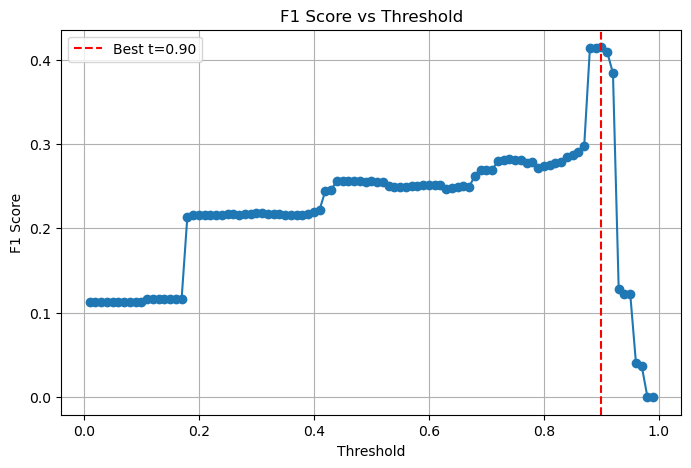

In [174]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()

In [175]:
Lookback = 48

X_train3d , y_train3d = lstm_seq(X_train,y_train,timesteps=Lookback)
X_valid3d , y_valid3d = lstm_seq(X_valid,y_valid,timesteps=Lookback)

In [176]:


# Changing sequences to PyTorch tensors

train_dataset = TensorDataset(torch.tensor(X_train3d, dtype=torch.float32),torch.tensor(y_train3d, dtype=torch.float32))
valid_dataset = TensorDataset(torch.tensor(X_valid3d, dtype=torch.float32),torch.tensor(y_valid3d, dtype=torch.float32))

# Initialize DataLoaders (Keep shuffle=False on validation to preserve chronological tracking)
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [177]:
model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()

pos_wt_val = torch.tensor([num_neg/num_pos],dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_wt_val)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

In [178]:
epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.5)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")

Starting training on device: mps

Epoch [01/15] -> Train Loss: 1.2723 | Val Loss: 2.5379 | Val F1-Score: 0.3403
Epoch [02/15] -> Train Loss: 1.1645 | Val Loss: 2.1977 | Val F1-Score: 0.2752
Epoch [03/15] -> Train Loss: 1.0840 | Val Loss: 2.0652 | Val F1-Score: 0.2749
Epoch [04/15] -> Train Loss: 1.0145 | Val Loss: 1.8145 | Val F1-Score: 0.2543
Epoch [05/15] -> Train Loss: 0.9661 | Val Loss: 1.7658 | Val F1-Score: 0.2487
Epoch [06/15] -> Train Loss: 0.9287 | Val Loss: 1.7016 | Val F1-Score: 0.2318
Epoch [07/15] -> Train Loss: 0.8988 | Val Loss: 1.6910 | Val F1-Score: 0.2384
Epoch [08/15] -> Train Loss: 0.8764 | Val Loss: 1.6557 | Val F1-Score: 0.2339
Epoch [09/15] -> Train Loss: 0.8662 | Val Loss: 1.6332 | Val F1-Score: 0.2303
Epoch [10/15] -> Train Loss: 0.8528 | Val Loss: 1.6477 | Val F1-Score: 0.2312
Epoch [11/15] -> Train Loss: 0.8401 | Val Loss: 1.5790 | Val F1-Score: 0.2300
Epoch [12/15] -> Train Loss: 0.8265 | Val Loss: 1.5756 | Val F1-Score: 0.2398
Epoch [13/15] -> Train Loss: 0

In [179]:
thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")

Best threshold: 0.860
Best F1: 0.3868


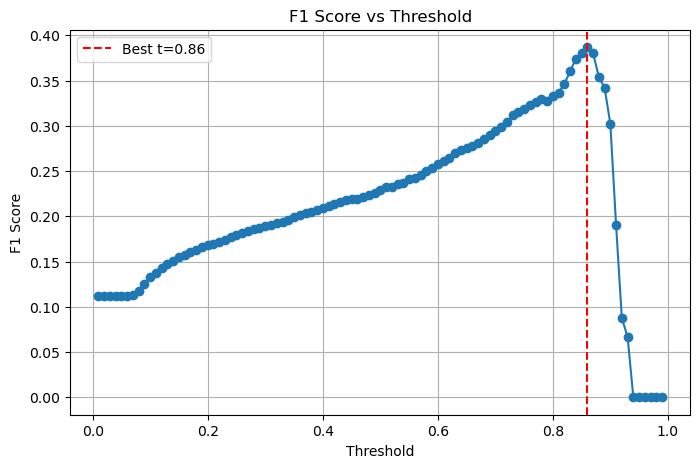

In [180]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()

In [181]:
print(f"Probs mean:{np.array(val_probs).mean()}")
print(f"Probs std:{np.array(val_probs).std()}")
print(f"Probs max:{np.array(val_probs).max()}")

Probs mean:0.4119850993156433
Probs std:0.2976095974445343
Probs max:0.9389635920524597


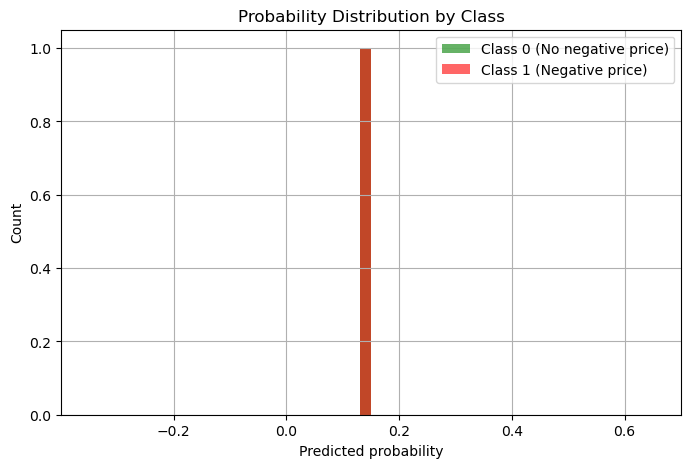

In [182]:
plt.figure(figsize=(8,5))

plt.hist(val_probs[val_targets == 0],
         bins=50,
         alpha=0.6,
         label="Class 0 (No negative price)",
         color="green")

plt.hist(val_probs[val_targets == 1],
         bins=50,
         alpha=0.6,
         label="Class 1 (Negative price)",
         color="red")


plt.title("Probability Distribution by Class")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

In [183]:
import torch.optim as optim

input_DIM = X_train3d.shape[2]
hidden_DIM = 128

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM,num_layers=2).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()

pos_wt_val = torch.tensor([num_neg/num_pos],dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_wt_val)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

In [184]:
epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.5)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")

Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.9774 | Val Loss: 1.8015 | Val F1-Score: 0.2285
Epoch [02/15] -> Train Loss: 0.7780 | Val Loss: 1.6233 | Val F1-Score: 0.2091
Epoch [03/15] -> Train Loss: 0.6875 | Val Loss: 1.7067 | Val F1-Score: 0.2566
Epoch [04/15] -> Train Loss: 0.6276 | Val Loss: 1.7814 | Val F1-Score: 0.2350
Epoch [05/15] -> Train Loss: 0.5647 | Val Loss: 1.9288 | Val F1-Score: 0.2560
Epoch [06/15] -> Train Loss: 0.5200 | Val Loss: 1.9385 | Val F1-Score: 0.2550
Epoch [07/15] -> Train Loss: 0.5069 | Val Loss: 2.1551 | Val F1-Score: 0.2374
Epoch [08/15] -> Train Loss: 0.4636 | Val Loss: 1.8325 | Val F1-Score: 0.2546
Epoch [09/15] -> Train Loss: 0.4208 | Val Loss: 2.1410 | Val F1-Score: 0.2757
Epoch [10/15] -> Train Loss: 0.4274 | Val Loss: 2.3458 | Val F1-Score: 0.2936
Epoch [11/15] -> Train Loss: 0.4043 | Val Loss: 2.1253 | Val F1-Score: 0.2831
Epoch [12/15] -> Train Loss: 0.4028 | Val Loss: 2.4157 | Val F1-Score: 0.2777
Epoch [13/15] -> Train Loss: 0

In [185]:
thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")

Best threshold: 0.900
Best F1: 0.3089


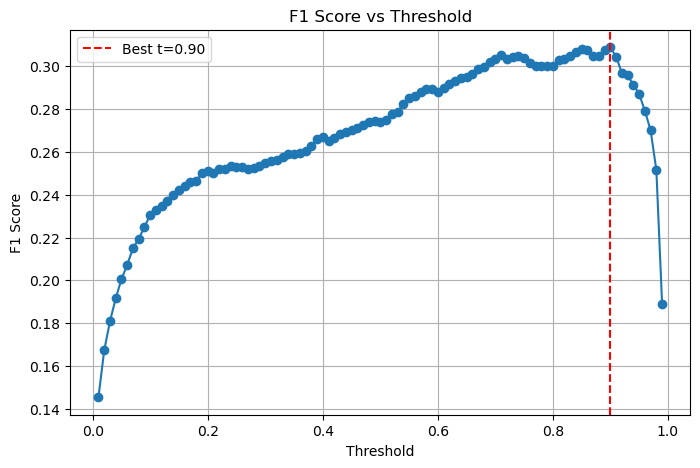

In [186]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()

In [187]:
X_train.columns[:40]

Index(['Biomass', 'Hydro', 'Wind_offshore', 'Photovolt', 'Lignite',
       'Fossil_gas', 'Hydro_pump_stor', 'Other_conv', 'Price', 'Other_ren',
       'Hour_sin', 'Hour_cos', 'Day_of_week_sin', 'Day_of_week_cos',
       'Month_sin', 'Month_cos'],
      dtype='str')

### Focal loss

In [188]:

import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # targets should be float (0/1)
        targets = targets.float()

        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)

        pt = torch.where(targets == 1, probs, 1 - probs)

        focal_weight = (1 - pt) ** self.gamma
        loss = self.alpha * focal_weight * bce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [189]:
input_DIM = X_train3d.shape[2]
hidden_DIM = 64

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM,num_layers=1).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()


criterion = FocalLoss(alpha=0.25, gamma=2.0)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

In [191]:
epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")

Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.0053 | Val Loss: 0.0122 | Val F1-Score: 0.1227
Epoch [02/15] -> Train Loss: 0.0053 | Val Loss: 0.0121 | Val F1-Score: 0.1218
Epoch [03/15] -> Train Loss: 0.0053 | Val Loss: 0.0121 | Val F1-Score: 0.1247
Epoch [04/15] -> Train Loss: 0.0052 | Val Loss: 0.0120 | Val F1-Score: 0.1252
Epoch [05/15] -> Train Loss: 0.0052 | Val Loss: 0.0120 | Val F1-Score: 0.1271
Epoch [06/15] -> Train Loss: 0.0052 | Val Loss: 0.0120 | Val F1-Score: 0.1383
Epoch [07/15] -> Train Loss: 0.0052 | Val Loss: 0.0120 | Val F1-Score: 0.1340
Epoch [08/15] -> Train Loss: 0.0051 | Val Loss: 0.0121 | Val F1-Score: 0.1365
Epoch [09/15] -> Train Loss: 0.0051 | Val Loss: 0.0119 | Val F1-Score: 0.1339
Epoch [10/15] -> Train Loss: 0.0051 | Val Loss: 0.0118 | Val F1-Score: 0.1392
Epoch [11/15] -> Train Loss: 0.0051 | Val Loss: 0.0119 | Val F1-Score: 0.1463
Epoch [12/15] -> Train Loss: 0.0051 | Val Loss: 0.0120 | Val F1-Score: 0.1424
Epoch [13/15] -> Train Loss: 0

In [192]:
thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")

Best threshold: 0.370
Best F1: 0.4016


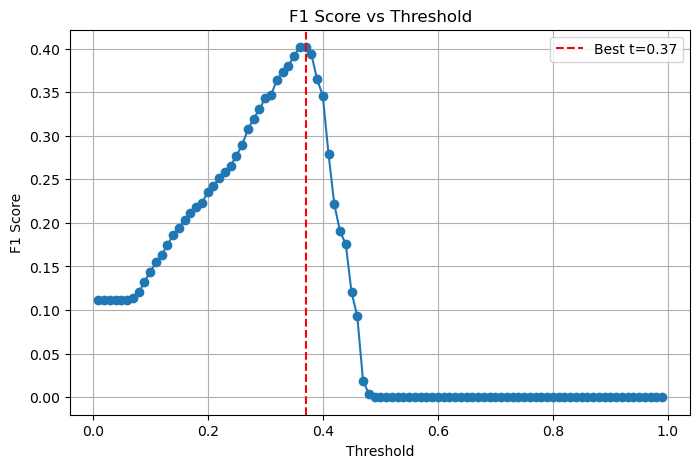

In [193]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()

### Changing hidden_DIM and layers

We now redo by varying hidden_DIM and num_layers <br>
To start with lets set hidden_DIM = 128 and num_layers= 1

In [195]:
input_DIM = X_train3d.shape[2]
hidden_DIM = 128

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM,num_layers=1).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()


criterion = FocalLoss(alpha=0.25, gamma=2.0)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

In [196]:
epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")

Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.0090 | Val Loss: 0.0124 | Val F1-Score: 0.1116
Epoch [02/15] -> Train Loss: 0.0057 | Val Loss: 0.0120 | Val F1-Score: 0.1153
Epoch [03/15] -> Train Loss: 0.0054 | Val Loss: 0.0120 | Val F1-Score: 0.1207
Epoch [04/15] -> Train Loss: 0.0053 | Val Loss: 0.0121 | Val F1-Score: 0.1259
Epoch [05/15] -> Train Loss: 0.0053 | Val Loss: 0.0121 | Val F1-Score: 0.1268
Epoch [06/15] -> Train Loss: 0.0052 | Val Loss: 0.0118 | Val F1-Score: 0.1263
Epoch [07/15] -> Train Loss: 0.0052 | Val Loss: 0.0119 | Val F1-Score: 0.1228
Epoch [08/15] -> Train Loss: 0.0052 | Val Loss: 0.0122 | Val F1-Score: 0.1262
Epoch [09/15] -> Train Loss: 0.0051 | Val Loss: 0.0120 | Val F1-Score: 0.1304
Epoch [10/15] -> Train Loss: 0.0050 | Val Loss: 0.0119 | Val F1-Score: 0.1313
Epoch [11/15] -> Train Loss: 0.0051 | Val Loss: 0.0127 | Val F1-Score: 0.1335
Epoch [12/15] -> Train Loss: 0.0050 | Val Loss: 0.0128 | Val F1-Score: 0.1453
Epoch [13/15] -> Train Loss: 0

In [197]:
thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")

Best threshold: 0.320
Best F1: 0.3586


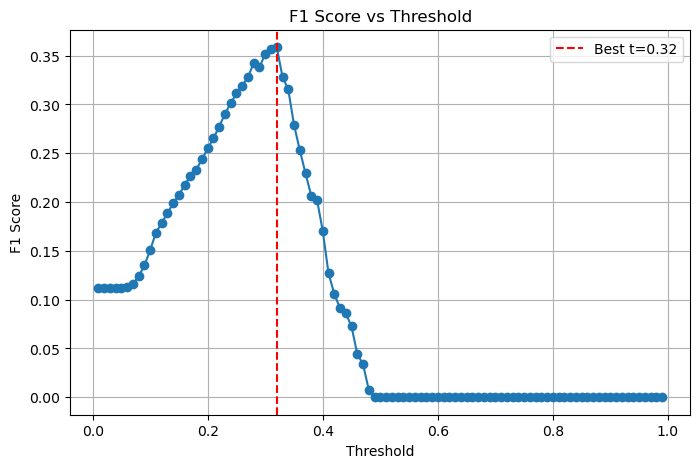

In [198]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()

Lets set hidden_DIM = 64 and num_layers= 2

In [199]:
input_DIM = X_train3d.shape[2]
hidden_DIM = 64

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM,num_layers=2).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()


criterion = FocalLoss(alpha=0.25, gamma=2.0)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

In [200]:
epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")

Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.0094 | Val Loss: 0.0129 | Val F1-Score: 0.1115
Epoch [02/15] -> Train Loss: 0.0055 | Val Loss: 0.0119 | Val F1-Score: 0.1224
Epoch [03/15] -> Train Loss: 0.0052 | Val Loss: 0.0120 | Val F1-Score: 0.1521
Epoch [04/15] -> Train Loss: 0.0051 | Val Loss: 0.0114 | Val F1-Score: 0.1453
Epoch [05/15] -> Train Loss: 0.0049 | Val Loss: 0.0115 | Val F1-Score: 0.1449
Epoch [06/15] -> Train Loss: 0.0048 | Val Loss: 0.0117 | Val F1-Score: 0.1549
Epoch [07/15] -> Train Loss: 0.0047 | Val Loss: 0.0123 | Val F1-Score: 0.1644
Epoch [08/15] -> Train Loss: 0.0045 | Val Loss: 0.0129 | Val F1-Score: 0.1703
Epoch [09/15] -> Train Loss: 0.0043 | Val Loss: 0.0138 | Val F1-Score: 0.1717
Epoch [10/15] -> Train Loss: 0.0043 | Val Loss: 0.0135 | Val F1-Score: 0.1740
Epoch [11/15] -> Train Loss: 0.0041 | Val Loss: 0.0141 | Val F1-Score: 0.1919
Epoch [12/15] -> Train Loss: 0.0039 | Val Loss: 0.0133 | Val F1-Score: 0.1712
Epoch [13/15] -> Train Loss: 0

In [201]:
thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")

Best threshold: 0.340
Best F1: 0.2918


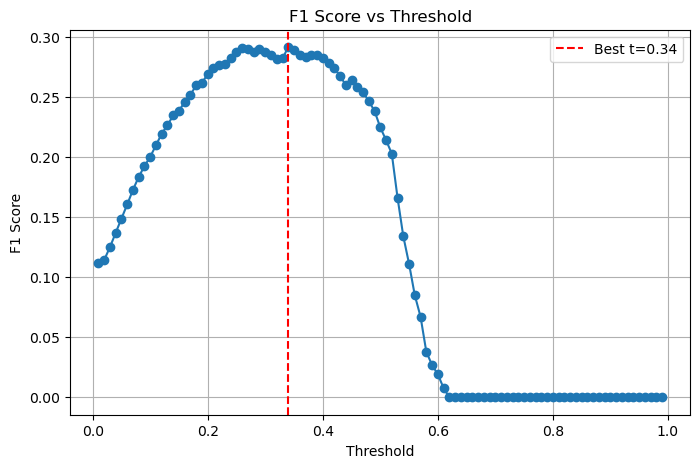

In [202]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()

In [203]:
input_DIM = X_train3d.shape[2]
hidden_DIM = 128

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM,num_layers=2).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()


criterion = FocalLoss(alpha=0.25, gamma=2.0)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

In [204]:
epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")

Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.0070 | Val Loss: 0.0126 | Val F1-Score: 0.1381
Epoch [02/15] -> Train Loss: 0.0050 | Val Loss: 0.0118 | Val F1-Score: 0.1528
Epoch [03/15] -> Train Loss: 0.0047 | Val Loss: 0.0122 | Val F1-Score: 0.1575
Epoch [04/15] -> Train Loss: 0.0044 | Val Loss: 0.0124 | Val F1-Score: 0.1473
Epoch [05/15] -> Train Loss: 0.0041 | Val Loss: 0.0123 | Val F1-Score: 0.1601
Epoch [06/15] -> Train Loss: 0.0039 | Val Loss: 0.0140 | Val F1-Score: 0.1928
Epoch [07/15] -> Train Loss: 0.0036 | Val Loss: 0.0136 | Val F1-Score: 0.1866
Epoch [08/15] -> Train Loss: 0.0032 | Val Loss: 0.0154 | Val F1-Score: 0.2215
Epoch [09/15] -> Train Loss: 0.0031 | Val Loss: 0.0143 | Val F1-Score: 0.1931
Epoch [10/15] -> Train Loss: 0.0030 | Val Loss: 0.0154 | Val F1-Score: 0.1945
Epoch [11/15] -> Train Loss: 0.0028 | Val Loss: 0.0198 | Val F1-Score: 0.2409
Epoch [12/15] -> Train Loss: 0.0026 | Val Loss: 0.0170 | Val F1-Score: 0.2164
Epoch [13/15] -> Train Loss: 0

In [205]:
thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")

Best threshold: 0.330
Best F1: 0.2995


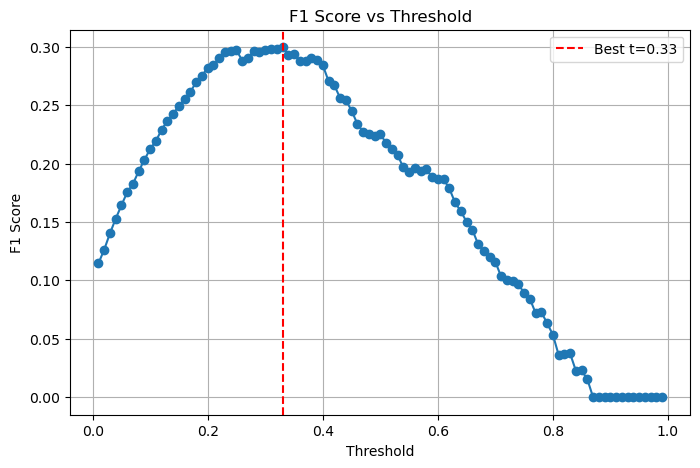

In [206]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()

### Changing time sequence

We fix hidden_DIM = 64 and num_layers= 1. Focal loss parameters are also kept the same. <br>
But we change lookback

In [211]:
Lookback = 24

X_train3d , y_train3d = lstm_seq(X_train,y_train,timesteps=Lookback)
X_valid3d , y_valid3d = lstm_seq(X_valid,y_valid,timesteps=Lookback)



# Changing sequences to PyTorch tensors

train_dataset = TensorDataset(torch.tensor(X_train3d, dtype=torch.float32),torch.tensor(y_train3d, dtype=torch.float32))
valid_dataset = TensorDataset(torch.tensor(X_valid3d, dtype=torch.float32),torch.tensor(y_valid3d, dtype=torch.float32))

# Initialize DataLoaders (Keep shuffle=False on validation to preserve chronological tracking)
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)




Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.0225 | Val Loss: 0.0128 | Val F1-Score: 0.1127
Epoch [02/15] -> Train Loss: 0.0071 | Val Loss: 0.0124 | Val F1-Score: 0.1127
Epoch [03/15] -> Train Loss: 0.0062 | Val Loss: 0.0129 | Val F1-Score: 0.1134
Epoch [04/15] -> Train Loss: 0.0061 | Val Loss: 0.0126 | Val F1-Score: 0.1140
Epoch [05/15] -> Train Loss: 0.0060 | Val Loss: 0.0125 | Val F1-Score: 0.1152
Epoch [06/15] -> Train Loss: 0.0059 | Val Loss: 0.0122 | Val F1-Score: 0.1204
Epoch [07/15] -> Train Loss: 0.0057 | Val Loss: 0.0123 | Val F1-Score: 0.1276
Epoch [08/15] -> Train Loss: 0.0057 | Val Loss: 0.0124 | Val F1-Score: 0.1267
Epoch [09/15] -> Train Loss: 0.0056 | Val Loss: 0.0123 | Val F1-Score: 0.1317
Epoch [10/15] -> Train Loss: 0.0056 | Val Loss: 0.0121 | Val F1-Score: 0.1300
Epoch [11/15] -> Train Loss: 0.0056 | Val Loss: 0.0121 | Val F1-Score: 0.1288
Epoch [12/15] -> Train Loss: 0.0055 | Val Loss: 0.0121 | Val F1-Score: 0.1314
Epoch [13/15] -> Train Loss: 0

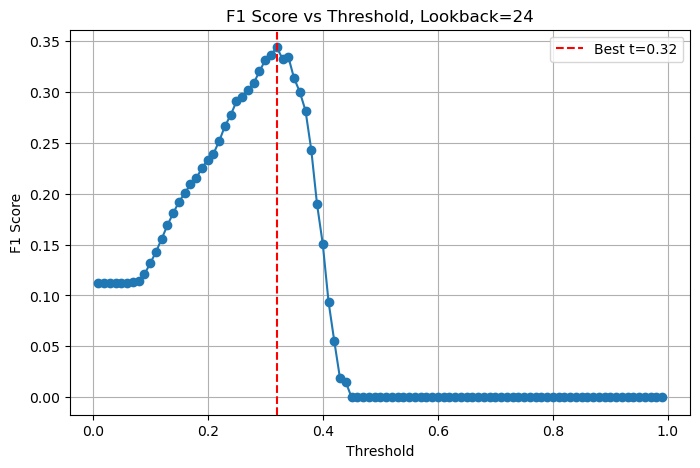

In [212]:
input_DIM = X_train3d.shape[2]
hidden_DIM = 64

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM,num_layers=1).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()


criterion = FocalLoss(alpha=0.25, gamma=2.0)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")
    

thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")


plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title(f"F1 Score vs Threshold, Lookback={Lookback}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()



In [207]:
Lookback = 72

X_train3d , y_train3d = lstm_seq(X_train,y_train,timesteps=Lookback)
X_valid3d , y_valid3d = lstm_seq(X_valid,y_valid,timesteps=Lookback)



# Changing sequences to PyTorch tensors

train_dataset = TensorDataset(torch.tensor(X_train3d, dtype=torch.float32),torch.tensor(y_train3d, dtype=torch.float32))
valid_dataset = TensorDataset(torch.tensor(X_valid3d, dtype=torch.float32),torch.tensor(y_valid3d, dtype=torch.float32))

# Initialize DataLoaders (Keep shuffle=False on validation to preserve chronological tracking)
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)




Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.0149 | Val Loss: 0.0125 | Val F1-Score: 0.1118
Epoch [02/15] -> Train Loss: 0.0066 | Val Loss: 0.0124 | Val F1-Score: 0.1119
Epoch [03/15] -> Train Loss: 0.0060 | Val Loss: 0.0121 | Val F1-Score: 0.1173
Epoch [04/15] -> Train Loss: 0.0057 | Val Loss: 0.0121 | Val F1-Score: 0.1191
Epoch [05/15] -> Train Loss: 0.0055 | Val Loss: 0.0121 | Val F1-Score: 0.1196
Epoch [06/15] -> Train Loss: 0.0055 | Val Loss: 0.0120 | Val F1-Score: 0.1199
Epoch [07/15] -> Train Loss: 0.0054 | Val Loss: 0.0120 | Val F1-Score: 0.1187
Epoch [08/15] -> Train Loss: 0.0053 | Val Loss: 0.0120 | Val F1-Score: 0.1270
Epoch [09/15] -> Train Loss: 0.0053 | Val Loss: 0.0120 | Val F1-Score: 0.1277
Epoch [10/15] -> Train Loss: 0.0053 | Val Loss: 0.0120 | Val F1-Score: 0.1338
Epoch [11/15] -> Train Loss: 0.0053 | Val Loss: 0.0118 | Val F1-Score: 0.1321
Epoch [12/15] -> Train Loss: 0.0053 | Val Loss: 0.0119 | Val F1-Score: 0.1359
Epoch [13/15] -> Train Loss: 0

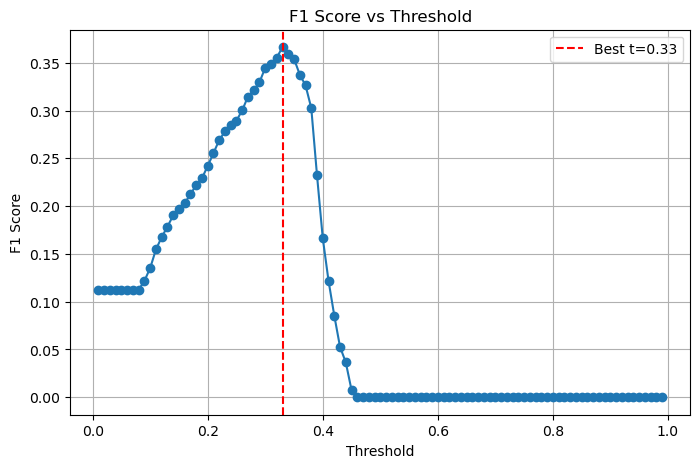

In [ ]:
input_DIM = X_train3d.shape[2]
hidden_DIM = 64

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM,num_layers=1).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()


criterion = FocalLoss(alpha=0.25, gamma=2.0)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")
    

thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")


plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title(f"F1 Score vs Threshold, Lookback={Lookback}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()



In [209]:
Lookback = 168

X_train3d , y_train3d = lstm_seq(X_train,y_train,timesteps=Lookback)
X_valid3d , y_valid3d = lstm_seq(X_valid,y_valid,timesteps=Lookback)



# Changing sequences to PyTorch tensors

train_dataset = TensorDataset(torch.tensor(X_train3d, dtype=torch.float32),torch.tensor(y_train3d, dtype=torch.float32))
valid_dataset = TensorDataset(torch.tensor(X_valid3d, dtype=torch.float32),torch.tensor(y_valid3d, dtype=torch.float32))

# Initialize DataLoaders (Keep shuffle=False on validation to preserve chronological tracking)
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)




Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.0112 | Val Loss: 0.0123 | Val F1-Score: 0.1130
Epoch [02/15] -> Train Loss: 0.0061 | Val Loss: 0.0120 | Val F1-Score: 0.1130
Epoch [03/15] -> Train Loss: 0.0058 | Val Loss: 0.0120 | Val F1-Score: 0.1130
Epoch [04/15] -> Train Loss: 0.0056 | Val Loss: 0.0118 | Val F1-Score: 0.1131
Epoch [05/15] -> Train Loss: 0.0054 | Val Loss: 0.0117 | Val F1-Score: 0.1147
Epoch [06/15] -> Train Loss: 0.0053 | Val Loss: 0.0118 | Val F1-Score: 0.1236
Epoch [07/15] -> Train Loss: 0.0052 | Val Loss: 0.0118 | Val F1-Score: 0.1252
Epoch [08/15] -> Train Loss: 0.0052 | Val Loss: 0.0117 | Val F1-Score: 0.1258
Epoch [09/15] -> Train Loss: 0.0052 | Val Loss: 0.0118 | Val F1-Score: 0.1224
Epoch [10/15] -> Train Loss: 0.0051 | Val Loss: 0.0118 | Val F1-Score: 0.1313
Epoch [11/15] -> Train Loss: 0.0052 | Val Loss: 0.0117 | Val F1-Score: 0.1313
Epoch [12/15] -> Train Loss: 0.0052 | Val Loss: 0.0117 | Val F1-Score: 0.1335
Epoch [13/15] -> Train Loss: 0

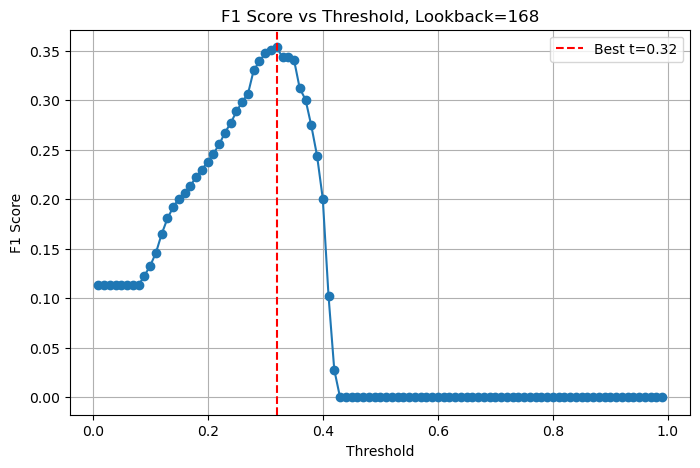

In [210]:
input_DIM = X_train3d.shape[2]
hidden_DIM = 64

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM,num_layers=1).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()


criterion = FocalLoss(alpha=0.25, gamma=2.0)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")
    

thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")


plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title(f"F1 Score vs Threshold, Lookback={Lookback}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()



Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.0131 | Val Loss: 0.0131 | Val F1-Score: 0.1121
Epoch [02/15] -> Train Loss: 0.0063 | Val Loss: 0.0131 | Val F1-Score: 0.1123
Epoch [03/15] -> Train Loss: 0.0059 | Val Loss: 0.0131 | Val F1-Score: 0.1130
Epoch [04/15] -> Train Loss: 0.0057 | Val Loss: 0.0128 | Val F1-Score: 0.1175
Epoch [05/15] -> Train Loss: 0.0055 | Val Loss: 0.0127 | Val F1-Score: 0.1186
Epoch [06/15] -> Train Loss: 0.0054 | Val Loss: 0.0127 | Val F1-Score: 0.1192
Epoch [07/15] -> Train Loss: 0.0054 | Val Loss: 0.0125 | Val F1-Score: 0.1195
Epoch [08/15] -> Train Loss: 0.0053 | Val Loss: 0.0123 | Val F1-Score: 0.1250
Epoch [09/15] -> Train Loss: 0.0053 | Val Loss: 0.0125 | Val F1-Score: 0.1191
Epoch [10/15] -> Train Loss: 0.0053 | Val Loss: 0.0125 | Val F1-Score: 0.1237
Epoch [11/15] -> Train Loss: 0.0052 | Val Loss: 0.0125 | Val F1-Score: 0.1294
Epoch [12/15] -> Train Loss: 0.0052 | Val Loss: 0.0122 | Val F1-Score: 0.1252
Epoch [13/15] -> Train Loss: 0

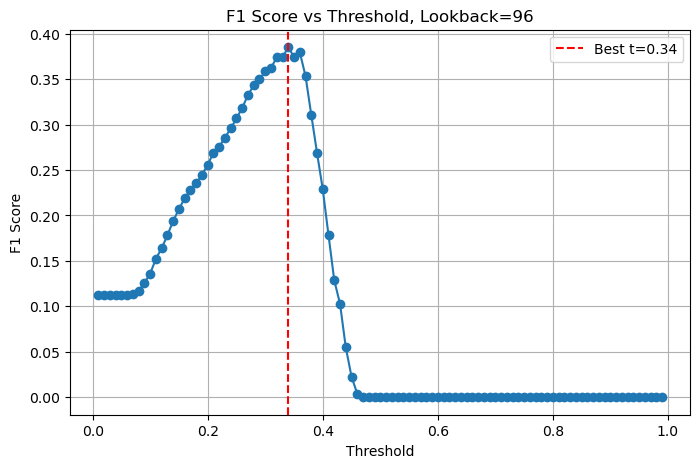

In [213]:
Lookback = 96

X_train3d , y_train3d = lstm_seq(X_train,y_train,timesteps=Lookback)
X_valid3d , y_valid3d = lstm_seq(X_valid,y_valid,timesteps=Lookback)



# Changing sequences to PyTorch tensors

train_dataset = TensorDataset(torch.tensor(X_train3d, dtype=torch.float32),torch.tensor(y_train3d, dtype=torch.float32))
valid_dataset = TensorDataset(torch.tensor(X_valid3d, dtype=torch.float32),torch.tensor(y_valid3d, dtype=torch.float32))

# Initialize DataLoaders (Keep shuffle=False on validation to preserve chronological tracking)
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)


input_DIM = X_train3d.shape[2]
hidden_DIM = 64

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM,num_layers=1).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()


criterion = FocalLoss(alpha=0.25, gamma=2.0)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")
    

thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")


plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title(f"F1 Score vs Threshold, Lookback={Lookback}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()



Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.0102 | Val Loss: 0.0134 | Val F1-Score: 0.1122
Epoch [02/15] -> Train Loss: 0.0060 | Val Loss: 0.0131 | Val F1-Score: 0.1127
Epoch [03/15] -> Train Loss: 0.0057 | Val Loss: 0.0126 | Val F1-Score: 0.1143
Epoch [04/15] -> Train Loss: 0.0056 | Val Loss: 0.0127 | Val F1-Score: 0.1186
Epoch [05/15] -> Train Loss: 0.0055 | Val Loss: 0.0124 | Val F1-Score: 0.1206
Epoch [06/15] -> Train Loss: 0.0054 | Val Loss: 0.0121 | Val F1-Score: 0.1258
Epoch [07/15] -> Train Loss: 0.0053 | Val Loss: 0.0119 | Val F1-Score: 0.1302
Epoch [08/15] -> Train Loss: 0.0053 | Val Loss: 0.0120 | Val F1-Score: 0.1323
Epoch [09/15] -> Train Loss: 0.0052 | Val Loss: 0.0118 | Val F1-Score: 0.1305
Epoch [10/15] -> Train Loss: 0.0052 | Val Loss: 0.0117 | Val F1-Score: 0.1305
Epoch [11/15] -> Train Loss: 0.0052 | Val Loss: 0.0118 | Val F1-Score: 0.1344
Epoch [12/15] -> Train Loss: 0.0052 | Val Loss: 0.0118 | Val F1-Score: 0.1415
Epoch [13/15] -> Train Loss: 0

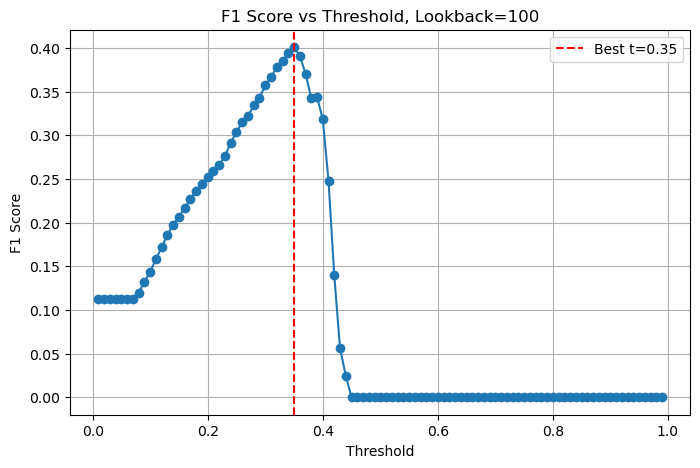

In [214]:
Lookback = 100

X_train3d , y_train3d = lstm_seq(X_train,y_train,timesteps=Lookback)
X_valid3d , y_valid3d = lstm_seq(X_valid,y_valid,timesteps=Lookback)



# Changing sequences to PyTorch tensors

train_dataset = TensorDataset(torch.tensor(X_train3d, dtype=torch.float32),torch.tensor(y_train3d, dtype=torch.float32))
valid_dataset = TensorDataset(torch.tensor(X_valid3d, dtype=torch.float32),torch.tensor(y_valid3d, dtype=torch.float32))

# Initialize DataLoaders (Keep shuffle=False on validation to preserve chronological tracking)
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)


input_DIM = X_train3d.shape[2]
hidden_DIM = 64

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM,num_layers=1).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()


criterion = FocalLoss(alpha=0.25, gamma=2.0)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")
    

thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")


plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title(f"F1 Score vs Threshold, Lookback={Lookback}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()



Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.0136 | Val Loss: 0.0136 | Val F1-Score: 0.1124
Epoch [02/15] -> Train Loss: 0.0063 | Val Loss: 0.0133 | Val F1-Score: 0.1126
Epoch [03/15] -> Train Loss: 0.0059 | Val Loss: 0.0127 | Val F1-Score: 0.1147
Epoch [04/15] -> Train Loss: 0.0056 | Val Loss: 0.0124 | Val F1-Score: 0.1195
Epoch [05/15] -> Train Loss: 0.0055 | Val Loss: 0.0121 | Val F1-Score: 0.1228
Epoch [06/15] -> Train Loss: 0.0054 | Val Loss: 0.0125 | Val F1-Score: 0.1285
Epoch [07/15] -> Train Loss: 0.0054 | Val Loss: 0.0125 | Val F1-Score: 0.1301
Epoch [08/15] -> Train Loss: 0.0053 | Val Loss: 0.0120 | Val F1-Score: 0.1323
Epoch [09/15] -> Train Loss: 0.0052 | Val Loss: 0.0123 | Val F1-Score: 0.1391
Epoch [10/15] -> Train Loss: 0.0052 | Val Loss: 0.0122 | Val F1-Score: 0.1517
Epoch [11/15] -> Train Loss: 0.0053 | Val Loss: 0.0122 | Val F1-Score: 0.1491
Epoch [12/15] -> Train Loss: 0.0053 | Val Loss: 0.0122 | Val F1-Score: 0.1405
Epoch [13/15] -> Train Loss: 0

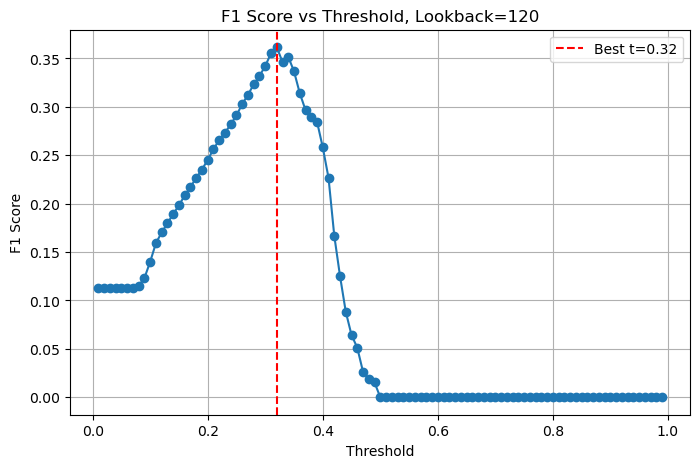

In [216]:
Lookback = 120

X_train3d , y_train3d = lstm_seq(X_train,y_train,timesteps=Lookback)
X_valid3d , y_valid3d = lstm_seq(X_valid,y_valid,timesteps=Lookback)



# Changing sequences to PyTorch tensors

train_dataset = TensorDataset(torch.tensor(X_train3d, dtype=torch.float32),torch.tensor(y_train3d, dtype=torch.float32))
valid_dataset = TensorDataset(torch.tensor(X_valid3d, dtype=torch.float32),torch.tensor(y_valid3d, dtype=torch.float32))

# Initialize DataLoaders (Keep shuffle=False on validation to preserve chronological tracking)
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)


input_DIM = X_train3d.shape[2]
hidden_DIM = 64

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM,num_layers=1).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()


criterion = FocalLoss(alpha=0.25, gamma=2.0)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")
    

thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")


plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title(f"F1 Score vs Threshold, Lookback={Lookback}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()



Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.0375 | Val Loss: 0.0187 | Val F1-Score: 0.1127
Epoch [02/15] -> Train Loss: 0.0086 | Val Loss: 0.0145 | Val F1-Score: 0.1127
Epoch [03/15] -> Train Loss: 0.0067 | Val Loss: 0.0133 | Val F1-Score: 0.1127
Epoch [04/15] -> Train Loss: 0.0062 | Val Loss: 0.0129 | Val F1-Score: 0.1128
Epoch [05/15] -> Train Loss: 0.0060 | Val Loss: 0.0126 | Val F1-Score: 0.1130
Epoch [06/15] -> Train Loss: 0.0058 | Val Loss: 0.0125 | Val F1-Score: 0.1149
Epoch [07/15] -> Train Loss: 0.0057 | Val Loss: 0.0126 | Val F1-Score: 0.1153
Epoch [08/15] -> Train Loss: 0.0057 | Val Loss: 0.0123 | Val F1-Score: 0.1155
Epoch [09/15] -> Train Loss: 0.0057 | Val Loss: 0.0122 | Val F1-Score: 0.1160
Epoch [10/15] -> Train Loss: 0.0056 | Val Loss: 0.0122 | Val F1-Score: 0.1159
Epoch [11/15] -> Train Loss: 0.0056 | Val Loss: 0.0121 | Val F1-Score: 0.1168
Epoch [12/15] -> Train Loss: 0.0055 | Val Loss: 0.0123 | Val F1-Score: 0.1162
Epoch [13/15] -> Train Loss: 0

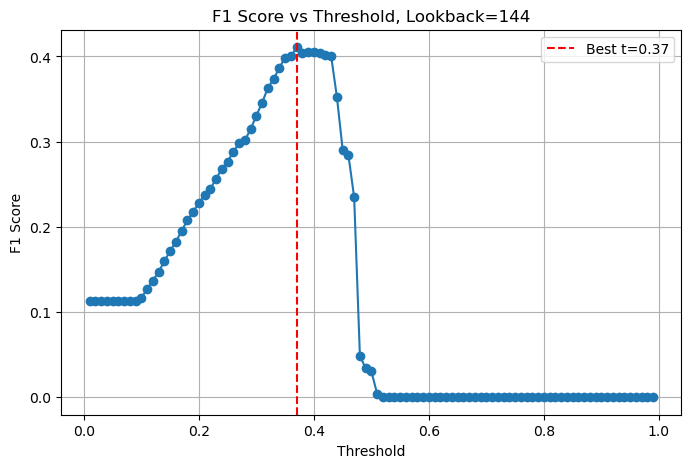

In [217]:
Lookback = 144

X_train3d , y_train3d = lstm_seq(X_train,y_train,timesteps=Lookback)
X_valid3d , y_valid3d = lstm_seq(X_valid,y_valid,timesteps=Lookback)



# Changing sequences to PyTorch tensors

train_dataset = TensorDataset(torch.tensor(X_train3d, dtype=torch.float32),torch.tensor(y_train3d, dtype=torch.float32))
valid_dataset = TensorDataset(torch.tensor(X_valid3d, dtype=torch.float32),torch.tensor(y_valid3d, dtype=torch.float32))

# Initialize DataLoaders (Keep shuffle=False on validation to preserve chronological tracking)
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)


input_DIM = X_train3d.shape[2]
hidden_DIM = 64

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM,num_layers=1).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()


criterion = FocalLoss(alpha=0.25, gamma=2.0)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")
    

thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")


plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title(f"F1 Score vs Threshold, Lookback={Lookback}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()



Starting training on device: mps

Epoch [01/15] -> Train Loss: 0.0165 | Val Loss: 0.0139 | Val F1-Score: 0.1130
Epoch [02/15] -> Train Loss: 0.0071 | Val Loss: 0.0132 | Val F1-Score: 0.1130
Epoch [03/15] -> Train Loss: 0.0064 | Val Loss: 0.0123 | Val F1-Score: 0.1131
Epoch [04/15] -> Train Loss: 0.0060 | Val Loss: 0.0121 | Val F1-Score: 0.1129
Epoch [05/15] -> Train Loss: 0.0058 | Val Loss: 0.0120 | Val F1-Score: 0.1128
Epoch [06/15] -> Train Loss: 0.0057 | Val Loss: 0.0122 | Val F1-Score: 0.1135
Epoch [07/15] -> Train Loss: 0.0056 | Val Loss: 0.0121 | Val F1-Score: 0.1147
Epoch [08/15] -> Train Loss: 0.0055 | Val Loss: 0.0122 | Val F1-Score: 0.1171
Epoch [09/15] -> Train Loss: 0.0055 | Val Loss: 0.0123 | Val F1-Score: 0.1205
Epoch [10/15] -> Train Loss: 0.0054 | Val Loss: 0.0118 | Val F1-Score: 0.1228
Epoch [11/15] -> Train Loss: 0.0055 | Val Loss: 0.0118 | Val F1-Score: 0.1193
Epoch [12/15] -> Train Loss: 0.0054 | Val Loss: 0.0121 | Val F1-Score: 0.1276
Epoch [13/15] -> Train Loss: 0

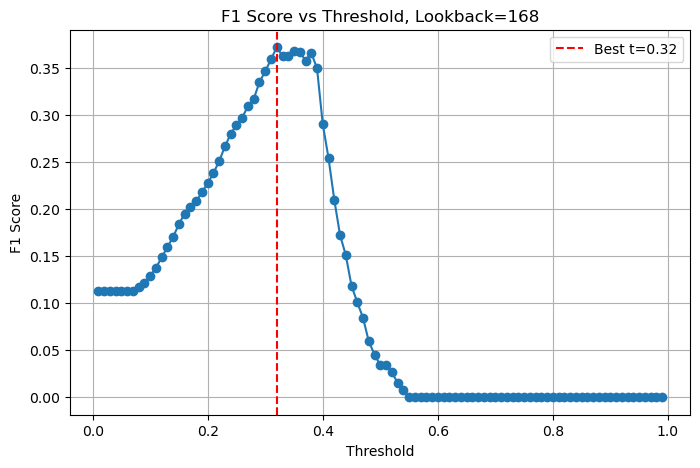

In [219]:
Lookback = 168

X_train3d , y_train3d = lstm_seq(X_train,y_train,timesteps=Lookback)
X_valid3d , y_valid3d = lstm_seq(X_valid,y_valid,timesteps=Lookback)



# Changing sequences to PyTorch tensors

train_dataset = TensorDataset(torch.tensor(X_train3d, dtype=torch.float32),torch.tensor(y_train3d, dtype=torch.float32))
valid_dataset = TensorDataset(torch.tensor(X_valid3d, dtype=torch.float32),torch.tensor(y_valid3d, dtype=torch.float32))

# Initialize DataLoaders (Keep shuffle=False on validation to preserve chronological tracking)
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)


input_DIM = X_train3d.shape[2]
hidden_DIM = 64

model = curtailment_LSTM(input_dim=input_DIM, hidden_dim=hidden_DIM,num_layers=1).to(device)

num_neg = (y_train3d == 0).sum()
num_pos = (y_train3d == 1).sum()


criterion = FocalLoss(alpha=0.25, gamma=2.0)

optimizer = optim.Adam(model.parameters(),lr=0.0001)

epochs = 15

print(f"Starting training on device: {device}\n")

best_model_state = None
best_val_loss    = float('inf')

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_f1, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        
    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"-> Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1-Score: {val_f1:.4f}")
    

thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

print(f"Best threshold: {best_t:.3f}")
print(f"Best F1: {best_f1:.4f}")


plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
plt.title(f"F1 Score vs Threshold, Lookback={Lookback}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()
plt.show()



In [ ]:
model.load_state_dict(best_model_state)

val_loss, val_f1, val_probs, val_targets = valid_epoch(
    model,
    valid_loader,
    criterion,
    device,
    threshold=0.1
)

In [230]:
def run_experiment(Lookback, X_train, y_train, X_valid, y_valid):
    
    print(f"\n Lookback = {Lookback} ")

    
    X_train3d, y_train3d = lstm_seq(X_train, y_train, timesteps=Lookback)
    X_valid3d, y_valid3d = lstm_seq(X_valid, y_valid, timesteps=Lookback)

    train_dataset = TensorDataset(torch.tensor(X_train3d, dtype=torch.float32),torch.tensor(y_train3d, dtype=torch.float32))

    valid_dataset = TensorDataset(torch.tensor(X_valid3d, dtype=torch.float32),torch.tensor(y_valid3d, dtype=torch.float32))

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

    
    input_dim = X_train3d.shape[2]
    model = curtailment_LSTM(input_dim=input_dim, hidden_dim=64, num_layers=1).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = FocalLoss(alpha=0.25, gamma=2.0)

    epochs = 15

    best_val_loss = float("inf")
    best_model_state = None

    # Training:
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1, val_probs, val_targets = valid_epoch(
            model, valid_loader, criterion, device, threshold=0.1
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()

        print(f"Epoch {epoch+1}/{epochs} | Train {train_loss:.4f} | Val {val_loss:.4f} | F1 {val_f1:.4f}")

    #  BEST model 
    model.load_state_dict(best_model_state)


    _, _, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)

    
    thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

    print(f"Best threshold: {best_t:.3f}")
    print(f"Best F1: {best_f1:.4f}")

    return best_f1, best_t

In [221]:
lookbacks = [24, 48, 72, 96, 100, 120, 144, 168]

results = []

for l in lookbacks:
    best_f1, best_t = run_experiment(l,X_train, y_train,X_valid, y_valid)
    
    results.append((l, best_f1, best_t))


 Lookback = 24 
Epoch 1/15 | Train 0.0101 | Val 0.0142 | F1 0.1127
Epoch 2/15 | Train 0.0062 | Val 0.0137 | F1 0.1177
Epoch 3/15 | Train 0.0059 | Val 0.0135 | F1 0.1189
Epoch 4/15 | Train 0.0057 | Val 0.0131 | F1 0.1217
Epoch 5/15 | Train 0.0056 | Val 0.0130 | F1 0.1274
Epoch 6/15 | Train 0.0055 | Val 0.0130 | F1 0.1280
Epoch 7/15 | Train 0.0055 | Val 0.0127 | F1 0.1258
Epoch 8/15 | Train 0.0054 | Val 0.0125 | F1 0.1358
Epoch 9/15 | Train 0.0053 | Val 0.0129 | F1 0.1350
Epoch 10/15 | Train 0.0053 | Val 0.0129 | F1 0.1313
Epoch 11/15 | Train 0.0052 | Val 0.0126 | F1 0.1327
Epoch 12/15 | Train 0.0052 | Val 0.0126 | F1 0.1347
Epoch 13/15 | Train 0.0052 | Val 0.0124 | F1 0.1457
Epoch 14/15 | Train 0.0052 | Val 0.0124 | F1 0.1344
Epoch 15/15 | Train 0.0052 | Val 0.0125 | F1 0.1377
Best threshold: 0.320
Best F1: 0.3434

 Lookback = 48 
Epoch 1/15 | Train 0.0202 | Val 0.0137 | F1 0.1115
Epoch 2/15 | Train 0.0069 | Val 0.0135 | F1 0.1116
Epoch 3/15 | Train 0.0062 | Val 0.0130 | F1 0.1120
Epoc

In [222]:
df_results = pd.DataFrame(results, columns=["Lookback", "Best_F1", "Best_Threshold"])
print(df_results)

   Lookback   Best_F1  Best_Threshold
0        24  0.343422            0.32
1        48  0.370277            0.33
2        72  0.387151            0.34
3        96  0.330055            0.32
4       100  0.372650            0.33
5       120  0.417887            0.37
6       144  0.347239            0.32
7       168  0.352130            0.34


In [223]:
import random

In [224]:
seeds = [4012,183,209]

results = []
lookback = 120

best_f1_scores = []
best_thresholds = []

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

for s in seeds:

    set_seed(s)
    print(f"Seed:{s}")

    best_f1, best_t = run_experiment(lookback,X_train, y_train,X_valid, y_valid)
    best_f1_scores.append(best_f1)
    best_thresholds.append(best_t)

print(f"\n Lookback: {lookback}")
print(f"Mean F1: {np.mean(best_f1_scores):.4f}")
print(f"Std  F1: {np.std(best_f1_scores):.4f}")
print(f"Mean threshold: {np.mean(best_thresholds):.3f}")

    

Seed:4012

 Lookback = 120 
Epoch 1/15 | Train 0.0178 | Val 0.0150 | F1 0.1124
Epoch 2/15 | Train 0.0066 | Val 0.0135 | F1 0.1125
Epoch 3/15 | Train 0.0059 | Val 0.0133 | F1 0.1176
Epoch 4/15 | Train 0.0057 | Val 0.0133 | F1 0.1238
Epoch 5/15 | Train 0.0056 | Val 0.0129 | F1 0.1283
Epoch 6/15 | Train 0.0055 | Val 0.0129 | F1 0.1262
Epoch 7/15 | Train 0.0054 | Val 0.0127 | F1 0.1328
Epoch 8/15 | Train 0.0054 | Val 0.0124 | F1 0.1291
Epoch 9/15 | Train 0.0054 | Val 0.0125 | F1 0.1379
Epoch 10/15 | Train 0.0053 | Val 0.0124 | F1 0.1382
Epoch 11/15 | Train 0.0053 | Val 0.0123 | F1 0.1373
Epoch 12/15 | Train 0.0053 | Val 0.0124 | F1 0.1392
Epoch 13/15 | Train 0.0052 | Val 0.0124 | F1 0.1367
Epoch 14/15 | Train 0.0052 | Val 0.0123 | F1 0.1360
Epoch 15/15 | Train 0.0052 | Val 0.0121 | F1 0.1343
Best threshold: 0.350
Best F1: 0.3787
Seed:183

 Lookback = 120 
Epoch 1/15 | Train 0.0138 | Val 0.0136 | F1 0.1124
Epoch 2/15 | Train 0.0066 | Val 0.0136 | F1 0.1124
Epoch 3/15 | Train 0.0060 | Val 0.

In [225]:
seeds = [4012,183,209]

results = []
lookback = 72

best_f1_scores = []
best_thresholds = []

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

for s in seeds:

    set_seed(s)
    print(f"Seed:{s}")

    best_f1, best_t = run_experiment(lookback,X_train, y_train,X_valid, y_valid)
    best_f1_scores.append(best_f1)
    best_thresholds.append(best_t)

print(f"\n Lookback: {lookback}")
print(f"Mean F1: {np.mean(best_f1_scores):.4f}")
print(f"Std  F1: {np.std(best_f1_scores):.4f}")
print(f"Mean threshold: {np.mean(best_thresholds):.3f}")

    

Seed:4012

 Lookback = 72 
Epoch 1/15 | Train 0.0178 | Val 0.0150 | F1 0.1118
Epoch 2/15 | Train 0.0067 | Val 0.0134 | F1 0.1119
Epoch 3/15 | Train 0.0059 | Val 0.0129 | F1 0.1141
Epoch 4/15 | Train 0.0057 | Val 0.0126 | F1 0.1169
Epoch 5/15 | Train 0.0056 | Val 0.0128 | F1 0.1191
Epoch 6/15 | Train 0.0055 | Val 0.0128 | F1 0.1192
Epoch 7/15 | Train 0.0055 | Val 0.0128 | F1 0.1227
Epoch 8/15 | Train 0.0054 | Val 0.0127 | F1 0.1241
Epoch 9/15 | Train 0.0054 | Val 0.0125 | F1 0.1308
Epoch 10/15 | Train 0.0053 | Val 0.0124 | F1 0.1385
Epoch 11/15 | Train 0.0054 | Val 0.0123 | F1 0.1457
Epoch 12/15 | Train 0.0053 | Val 0.0124 | F1 0.1377
Epoch 13/15 | Train 0.0054 | Val 0.0123 | F1 0.1431
Epoch 14/15 | Train 0.0053 | Val 0.0122 | F1 0.1337
Epoch 15/15 | Train 0.0053 | Val 0.0123 | F1 0.1250
Best threshold: 0.340
Best F1: 0.3764
Seed:183

 Lookback = 72 
Epoch 1/15 | Train 0.0143 | Val 0.0137 | F1 0.1118
Epoch 2/15 | Train 0.0066 | Val 0.0133 | F1 0.1118
Epoch 3/15 | Train 0.0060 | Val 0.01

In [226]:
seeds = [4012,183,209]

results = []
lookback = 144

best_f1_scores = []
best_thresholds = []

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

for s in seeds:

    set_seed(s)
    print(f"Seed:{s}")

    best_f1, best_t = run_experiment(lookback,X_train, y_train,X_valid, y_valid)
    best_f1_scores.append(best_f1)
    best_thresholds.append(best_t)

print(f"\n Lookback: {lookback}")
print(f"Mean F1: {np.mean(best_f1_scores):.4f}")
print(f"Std  F1: {np.std(best_f1_scores):.4f}")
print(f"Mean threshold: {np.mean(best_thresholds):.3f}")

    

Seed:4012

 Lookback = 144 
Epoch 1/15 | Train 0.0182 | Val 0.0151 | F1 0.1127
Epoch 2/15 | Train 0.0066 | Val 0.0136 | F1 0.1127
Epoch 3/15 | Train 0.0058 | Val 0.0132 | F1 0.1136
Epoch 4/15 | Train 0.0056 | Val 0.0128 | F1 0.1148
Epoch 5/15 | Train 0.0055 | Val 0.0125 | F1 0.1156
Epoch 6/15 | Train 0.0054 | Val 0.0127 | F1 0.1237
Epoch 7/15 | Train 0.0054 | Val 0.0125 | F1 0.1259
Epoch 8/15 | Train 0.0054 | Val 0.0125 | F1 0.1265
Epoch 9/15 | Train 0.0053 | Val 0.0125 | F1 0.1287
Epoch 10/15 | Train 0.0053 | Val 0.0125 | F1 0.1337
Epoch 11/15 | Train 0.0052 | Val 0.0126 | F1 0.1405
Epoch 12/15 | Train 0.0052 | Val 0.0124 | F1 0.1412
Epoch 13/15 | Train 0.0052 | Val 0.0128 | F1 0.1387
Epoch 14/15 | Train 0.0052 | Val 0.0127 | F1 0.1396
Epoch 15/15 | Train 0.0052 | Val 0.0126 | F1 0.1335
Best threshold: 0.360
Best F1: 0.3677
Seed:183

 Lookback = 144 
Epoch 1/15 | Train 0.0138 | Val 0.0139 | F1 0.1127
Epoch 2/15 | Train 0.0065 | Val 0.0133 | F1 0.1127
Epoch 3/15 | Train 0.0060 | Val 0.

So we will continue with lookback = 72. We will now increase the number of epochs and use early stopping

In [233]:
# Training loop with early stopping

def run_experiment_long(Lookback, X_train, y_train, X_valid, y_valid, epochs=50, patience=5):
    
    print(f"\n Lookback = {Lookback} ")

    
    X_train3d, y_train3d = lstm_seq(X_train, y_train, timesteps=Lookback)
    X_valid3d, y_valid3d = lstm_seq(X_valid, y_valid, timesteps=Lookback)

    train_dataset = TensorDataset(torch.tensor(X_train3d, dtype=torch.float32),torch.tensor(y_train3d, dtype=torch.float32))

    valid_dataset = TensorDataset(torch.tensor(X_valid3d, dtype=torch.float32),torch.tensor(y_valid3d, dtype=torch.float32))

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

    
    input_dim = X_train3d.shape[2]
    model = curtailment_LSTM(input_dim=input_dim, hidden_dim=64, num_layers=1).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = FocalLoss(alpha=0.25, gamma=2.0)

    

    best_val_loss = float("inf")
    best_model_state = None
    patience = 5
    counter = 0
    
    # Training:
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1, val_probs, val_targets = valid_epoch(
            model, valid_loader, criterion, device, threshold=0.1
        )
        print(f"Epoch {epoch+1}/{epochs} | Train {train_loss:.4f} | Val {val_loss:.4f} | F1 {val_f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            counter = 0
        else:
            counter += 1

        if counter > patience:
            print(f"Early stopping epoch : {epoch+1}")
            break

        

    #  BEST model 
    model.load_state_dict(best_model_state)


    _, _, val_probs, val_targets = valid_epoch(model, valid_loader, criterion, device, threshold=0.1)

    
    thresholds, f1_scores, best_t, best_f1 = threshold_sweep(val_targets, val_probs)

    print(f"Best threshold: {best_t:.3f}")
    print(f"Best F1: {best_f1:.4f}")

    return best_f1, best_t

In [241]:

results  = []
epochs   = 50
patience = 6
lookback = 72
best_f1_scores = []
best_thresholds = []
seeds = [42,183,209]

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


for s in seeds:

    set_seed(s)
    print(f"Seed:{s}")

    best_f1, best_t = run_experiment_long(lookback,X_train, y_train,X_valid, y_valid,epochs=50,patience=6)
    best_f1_scores.append(best_f1)
    best_thresholds.append(best_t)

print(f"\n Lookback: {lookback}")
print(f"Mean F1: {np.mean(best_f1_scores):.4f}")
print(f"Std  F1: {np.std(best_f1_scores):.4f}")
print(f"Mean threshold: {np.mean(best_thresholds):.3f}")

    

Seed:42

 Lookback = 72 
Epoch 1/50 | Train 0.0186 | Val 0.0128 | F1 0.1118
Epoch 2/50 | Train 0.0068 | Val 0.0125 | F1 0.1119
Epoch 3/50 | Train 0.0060 | Val 0.0126 | F1 0.1138
Epoch 4/50 | Train 0.0057 | Val 0.0122 | F1 0.1241
Epoch 5/50 | Train 0.0055 | Val 0.0123 | F1 0.1288
Epoch 6/50 | Train 0.0053 | Val 0.0122 | F1 0.1317
Epoch 7/50 | Train 0.0053 | Val 0.0124 | F1 0.1356
Epoch 8/50 | Train 0.0053 | Val 0.0123 | F1 0.1327
Epoch 9/50 | Train 0.0053 | Val 0.0120 | F1 0.1370
Epoch 10/50 | Train 0.0052 | Val 0.0119 | F1 0.1284
Epoch 11/50 | Train 0.0052 | Val 0.0118 | F1 0.1358
Epoch 12/50 | Train 0.0051 | Val 0.0118 | F1 0.1386
Epoch 13/50 | Train 0.0051 | Val 0.0119 | F1 0.1356
Epoch 14/50 | Train 0.0052 | Val 0.0120 | F1 0.1356
Epoch 15/50 | Train 0.0051 | Val 0.0121 | F1 0.1420
Epoch 16/50 | Train 0.0051 | Val 0.0123 | F1 0.1454
Epoch 17/50 | Train 0.0051 | Val 0.0118 | F1 0.1356
Early stopping epoch : 17
Best threshold: 0.340
Best F1: 0.3860
Seed:183

 Lookback = 72 
Epoch 1/50